In [1]:
import numpy 
import torch
import matplotlib.pyplot as plt

In [2]:
words = open("../../datasets/names/names.txt", "r").read().splitlines()

In [3]:
words[:10]

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

In [4]:
len(words)

32033

```
Real Structure of .get()
dictionary.get(key, default_value)
Meaning:
Try finding key.
If found -> return value of that dict key.
Else -> return default_value.
```

In [5]:
bigram_count = {}
for w in words:
    swe = ["<S>"] + list(w) + ["<E>"] #["<s>", "e", "m", ..., "<e>"]
    for ch1, ch2 in zip(swe, swe[1:]): #("<s>", "<e>"), ...
        bigram = (ch1, ch2)
        bigram_count[bigram] = bigram_count.get(bigram, 0) + 1

In [6]:
high_to_low_bicount = sorted(bigram_count.items(), key= lambda kv:kv[1], reverse=True)

In [7]:
chars = sorted(list(set("".join(words))))
chars.insert(0, ".") #instead of <S> and <E> we will use . that indicates start as well as stop


In [8]:
N = torch.zeros((27,27), dtype = torch.int32)

In [9]:
for w in words:
    swe = ["."] + list(w) + ["."] #we will use . instead of <s> and <e> to indicate the start and end of a word
    for ch1, ch2 in zip(swe, swe[1:]):
        index1 = chars.index(ch1)
        index2 = chars.index(ch2)
        N[index1, index2] += 1

In [10]:
N

tensor([[   0, 4410, 1306, 1542, 1690, 1531,  417,  669,  874,  591, 2422, 2963,
         1572, 2538, 1146,  394,  515,   92, 1639, 2055, 1308,   78,  376,  307,
          134,  535,  929],
        [6640,  556,  541,  470, 1042,  692,  134,  168, 2332, 1650,  175,  568,
         2528, 1634, 5438,   63,   82,   60, 3264, 1118,  687,  381,  834,  161,
          182, 2050,  435],
        [ 114,  321,   38,    1,   65,  655,    0,    0,   41,  217,    1,    0,
          103,    0,    4,  105,    0,    0,  842,    8,    2,   45,    0,    0,
            0,   83,    0],
        [  97,  815,    0,   42,    1,  551,    0,    2,  664,  271,    3,  316,
          116,    0,    0,  380,    1,   11,   76,    5,   35,   35,    0,    0,
            3,  104,    4],
        [ 516, 1303,    1,    3,  149, 1283,    5,   25,  118,  674,    9,    3,
           60,   30,   31,  378,    0,    1,  424,   29,    4,   92,   17,   23,
            0,  317,    1],
        [3983,  679,  121,  153,  384, 1271,   82,

(-0.5, 26.5, 26.5, -0.5)

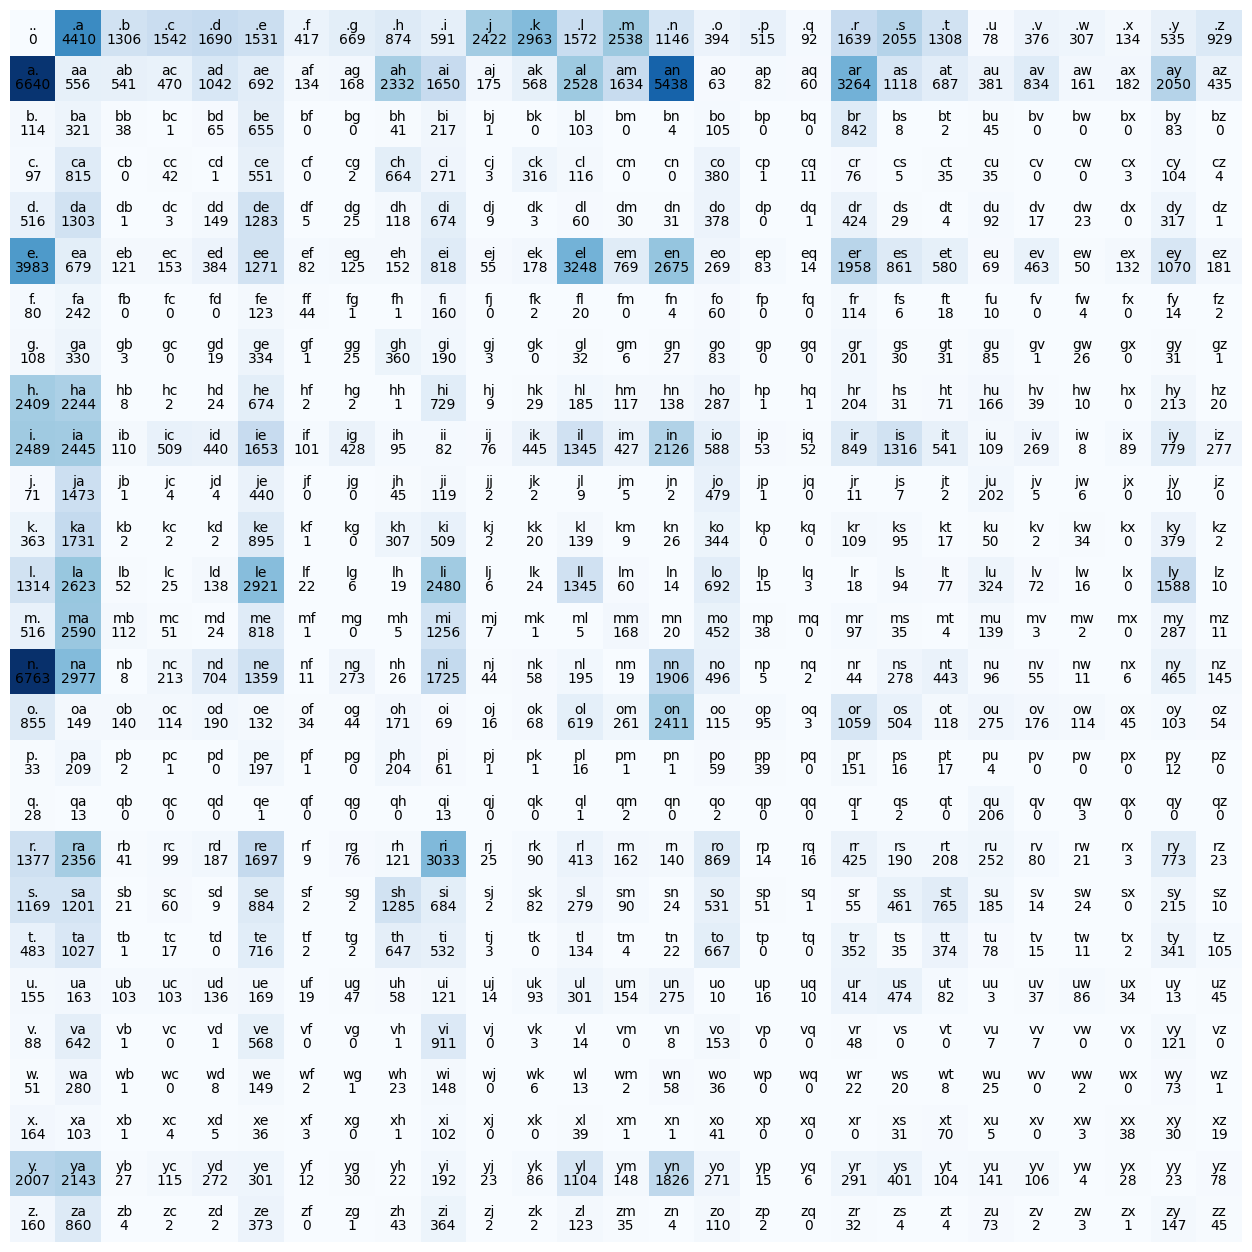

In [11]:
plt.figure(figsize=(16,16))
plt.imshow(N.cpu().numpy(), cmap = "Blues")
for i in range(27):
    for j in range(27):
        chstr = chars[i] + chars[j]
        plt.text(j, i, chstr, ha = "center", va = "bottom") #places text at j, i
        plt.text(j, i, N[i,j].item(), ha = "center", va = "top")

plt.axis("off")

In [12]:
N[0]
# idx = N[0]
# p = idx / idx.sum()
# torch.multinomial(p, num_samples = 1, replacement = True)

tensor([   0, 4410, 1306, 1542, 1690, 1531,  417,  669,  874,  591, 2422, 2963,
        1572, 2538, 1146,  394,  515,   92, 1639, 2055, 1308,   78,  376,  307,
         134,  535,  929], dtype=torch.int32)

In [13]:
P = (N+1).float() # added 1 to smooth out the model, see below for explanation as to why.
P /= P.sum(1, keepdims = True)

In [14]:
g = torch.Generator().manual_seed(42) 
for i in range(20):
    out = []
    index = 0
    while True:
        p = P[index]
        index = torch.multinomial(p, num_samples = 1, replacement = True, generator = g).item()
        out.append(chars[index])
        if index == 0:
            break
    print("".join(out))
        

ya.
syahavilin.
dleekahmangonya.
tryahe.
chen.
ena.
da.
amiiae.
a.
keles.
ly.
a.
oy.
asityi.
pepolannezale.
shahlamion.
nacelucyanarivieriaquten.
kigshmole.
ei.
tonylyan.


In [15]:
#calculating the negative likehood which wil be used as a loss functiont to train the model
log_likehood = 0
n = 0
nll = 0
for w in words:
    swe = ["."] + list(w) + ["."]
    for ch1, ch2 in zip(swe, swe[1:]):
        index1 = chars.index(ch1)
        index2 = chars.index(ch2)
        prob = P[index1, index2]
        log_likehood += torch.log(prob)
        n += 1
        # print(f"{ch1} {ch2}, {prob:4f}, {log_likehood:4f} ")
        
nll = - log_likehood   
print(f"{log_likehood = }")
print(f"average negative_likehood = {(nll/n):4f}")

log_likehood = tensor(-559951.5625)
average negative_likehood = 2.454356


In [16]:
#what if you have a word that contains two characters that have 0 probability to occur, e.g.:
log_likehood = 0
n = 0
nll = 0
for w in ["akhileshx"]:
    swe = ["."] + list(w) + ["."]
    for ch1, ch2 in zip(swe, swe[1:]):
        index1 = chars.index(ch1)
        index2 = chars.index(ch2)
        prob = P[index1, index2]
        log_likehood += torch.log(prob)
        n += 1
        print(f"{ch1} {ch2}, {prob:4f}, {log_likehood:4f} ")
        
nll = - log_likehood   
print(f"{log_likehood = }")
print(f"average negative_likehood = {(nll/n):4f}")

. a, 0.137586, -1.983508 
a k, 0.016779, -6.071151 
k h, 0.060785, -8.871555 
h i, 0.095512, -11.220057 
i l, 0.075925, -13.798065 
l e, 0.208938, -15.363782 
e s, 0.042152, -18.530266 
s h, 0.158121, -20.374659 
h x, 0.000131, -29.316204 
x ., 0.227901, -30.795050 
log_likehood = tensor(-30.7950)
average negative_likehood = 3.079505


In [17]:
#hx has 0 probability to occur so the model outputs inf, so just to smooth out the model, we will add 1(you can add any number) to atleast have a probability that it will occur once
#create training set of bigrams
xs, ys = [], []
for w in words[:1]:
    swe = ["."] + list(w) + ["."]
    for ch1, ch2 in zip(swe, swe[1:]):
        index1 = chars.index(ch1)
        index2 = chars.index(ch2)
        print(ch1, ch2)
        xs.append(index1)
        ys.append(index2)
        
xs = torch.tensor(xs)
ys = torch.tensor(ys) # you can also use torch.Tensor() but this would return dtype as torch.float64
        

. e
e m
m m
m a
a .


In [18]:
xs # stors the present character index

tensor([ 0,  5, 13, 13,  1])

In [19]:
ys #stores the character index that should be followed after the xs, so if xs = 0 then next words ia at index ys = 5 with emma being the example.

tensor([ 5, 13, 13,  1,  0])

In [20]:
#we will be passing this to a neural network to minimize the loss function which is negative log here,
#now to pass to a neural net we first want to convert the raw index list to one hot encoded vector.
import torch.nn.functional as F
xenc = F.one_hot(xs, num_classes=27).float() #(5,27)
xenc

tensor([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.]])

In [21]:
g = torch.Generator().manual_seed(42)
w = torch.randn((27,27), generator=g) # takes 27 input features and has 27 neurons

In [22]:
logits = xenc @ w 
counts = logits.exp()
prob = counts / counts.sum(1, keepdims = True)
prob
# this is just softmax function broken down into simpler terms i.e. softmax = exp(logits)/sum(exp(logits))


tensor([[0.1230, 0.0793, 0.0441, 0.0022, 0.0353, 0.0052, 0.0172, 0.0036, 0.0084,
         0.0932, 0.0121, 0.0044, 0.0087, 0.0102, 0.0083, 0.0384, 0.0926, 0.0153,
         0.0109, 0.0278, 0.0084, 0.0527, 0.0399, 0.0962, 0.0644, 0.0655, 0.0330],
        [0.0396, 0.0698, 0.0227, 0.0037, 0.0562, 0.0153, 0.0626, 0.0112, 0.0421,
         0.0084, 0.0581, 0.1125, 0.0951, 0.0292, 0.0181, 0.0107, 0.0247, 0.0316,
         0.0586, 0.0140, 0.1109, 0.0019, 0.0147, 0.0067, 0.0502, 0.0033, 0.0280],
        [0.0123, 0.0078, 0.0250, 0.0187, 0.0050, 0.0125, 0.0074, 0.0099, 0.1254,
         0.1147, 0.0934, 0.0176, 0.0144, 0.0029, 0.0085, 0.0116, 0.1132, 0.0138,
         0.0203, 0.1464, 0.0943, 0.0242, 0.0326, 0.0140, 0.0340, 0.0149, 0.0053],
        [0.0123, 0.0078, 0.0250, 0.0187, 0.0050, 0.0125, 0.0074, 0.0099, 0.1254,
         0.1147, 0.0934, 0.0176, 0.0144, 0.0029, 0.0085, 0.0116, 0.1132, 0.0138,
         0.0203, 0.1464, 0.0943, 0.0242, 0.0326, 0.0140, 0.0340, 0.0149, 0.0053],
        [0.0934, 0.0195,

In [23]:
prob[0,:].sum()

tensor(1.0000)

In [24]:
#check how the model is actually predicting the outputs now
#print the input to the model,
#print the probabilities,
#print the actual next character,
#print the probability the model assigns to this next character,
#print the negative log likelihood,
#at the end print the total loss i.e. average negative log likehood.
nll = torch.zeros(5)
for i in range(5):
    x = xs[i].item()
    y = ys[i].item()
    print("---------------------")
    print(f"bigram example {i}:")
    print(f"input to the neural net: {x}")
    print(f"output probabilities: {prob[i]}")
    print("actual next character is at: ", y)
    p = prob[i, y]
    print(f"probability assigned to character at {y} by the model: {p.item()}")
    log = -torch.log(p)
    print(f"negative log likelihood: {log.item()}")
    nll[i] = log
    
print("average negative likelihood: ", nll.mean().item())

---------------------
bigram example 0:
input to the neural net: 0
output probabilities: tensor([0.1230, 0.0793, 0.0441, 0.0022, 0.0353, 0.0052, 0.0172, 0.0036, 0.0084,
        0.0932, 0.0121, 0.0044, 0.0087, 0.0102, 0.0083, 0.0384, 0.0926, 0.0153,
        0.0109, 0.0278, 0.0084, 0.0527, 0.0399, 0.0962, 0.0644, 0.0655, 0.0330])
actual next character is at:  5
probability assigned to character at 5 by the model: 0.005211981479078531
negative log likelihood: 5.256795406341553
---------------------
bigram example 1:
input to the neural net: 5
output probabilities: tensor([0.0396, 0.0698, 0.0227, 0.0037, 0.0562, 0.0153, 0.0626, 0.0112, 0.0421,
        0.0084, 0.0581, 0.1125, 0.0951, 0.0292, 0.0181, 0.0107, 0.0247, 0.0316,
        0.0586, 0.0140, 0.1109, 0.0019, 0.0147, 0.0067, 0.0502, 0.0033, 0.0280])
actual next character is at:  13
probability assigned to character at 13 by the model: 0.029176028445363045
negative log likelihood: 3.5344078540802
---------------------
bigram example 2:
in

----optimization-------

In [25]:
xs

tensor([ 0,  5, 13, 13,  1])

In [26]:
ys

tensor([ 5, 13, 13,  1,  0])

In [27]:
#forward pass in bigram model:
#initialize a random weight
#one hot encode the input
#multiply weight with the input
#caculate the probability
#caculate the loss

In [28]:
xs, ys = [], []
for w in words:
    swe = ["."] + list(w) + ["."]
    for ch1, ch2 in zip(swe, swe[1:]):
        index1 = chars.index(ch1)
        index2 = chars.index(ch2)
        # print(ch1, ch2)
        xs.append(index1)
        ys.append(index2)
        
xs = torch.tensor(xs)
ys = torch.tensor(ys)
num = len(xs)
print("number of examples = ", num)

number of examples =  228146


In [29]:
g = torch.Generator().manual_seed(42)
w = torch.randn((27,27), generator = g, requires_grad = True) #requires_grad tells the torch that we would like to calculate grad of w

In [30]:
for iteration in range(100):
    one_hot_x = F.one_hot(xs, num_classes=27).float()
    logits = one_hot_x @ w
    counts = logits.exp()
    probs = counts/counts.sum(1, keepdims = True)
    loss = -probs[torch.arange(num), ys].log().mean() + 0.01 * (w**2).mean() #applying l2 regularization
    print(f"loss in iteration {iteration + 1} = {loss}")
    w.grad = None # if set to 0 torch will interpret it as value 0 not as w.grad doesn't exist
    loss.backward()
    w.data += -50 * w.grad


loss in iteration 1 = 3.7064766883850098
loss in iteration 2 = 3.373866081237793
loss in iteration 3 = 3.1580393314361572
loss in iteration 4 = 3.015209436416626
loss in iteration 5 = 2.9186456203460693
loss in iteration 6 = 2.847991704940796
loss in iteration 7 = 2.794921398162842
loss in iteration 8 = 2.754241943359375
loss in iteration 9 = 2.722402334213257
loss in iteration 10 = 2.6969127655029297
loss in iteration 11 = 2.6760473251342773
loss in iteration 12 = 2.6586241722106934
loss in iteration 13 = 2.643829345703125
loss in iteration 14 = 2.6310930252075195
loss in iteration 15 = 2.6200039386749268
loss in iteration 16 = 2.610257863998413
loss in iteration 17 = 2.6016247272491455
loss in iteration 18 = 2.593924045562744
loss in iteration 19 = 2.587015151977539
loss in iteration 20 = 2.580784320831299
loss in iteration 21 = 2.575138568878174
loss in iteration 22 = 2.5700018405914307
loss in iteration 23 = 2.5653107166290283
loss in iteration 24 = 2.5610108375549316
loss in itera

In [ ]:
#All we did in the second half is use neural network to automate the process 

In [32]:
#just experimenting
g = torch.Generator().manual_seed(43)
w2 = torch.randn((27,27), requires_grad = True)
w3 = torch.randn((27,27), requires_grad = True)

In [38]:
for iteration in range(10):
    one_hot_x = F.one_hot(xs, num_classes=27).float()
    logits = one_hot_x @ w
    a1 = torch.tanh(logits)
    #layer2
    logits2 = a1 @ w2
    a2 = torch.tanh(logits2)
    #layer3 
    logits3 = a2 @ w3
    counts = logits3.exp()
    probs = counts/counts.sum(1, keepdims = True)
    loss = -probs[torch.arange(num), ys].log().mean() + 0.01 * (w**2).mean() #applying l2 regularization
    print(f"loss in iteration {iteration + 1} = {loss}")
    w.grad = None # if set to 0 torch will interpret it as value 0 not as w.grad doesn't exist
    loss.backward()
    w.data += -0.1 * w.grad
    w2.data += -0.1 * w2.grad


loss in iteration 1 = 10.391718864440918
loss in iteration 2 = 10.391706466674805
loss in iteration 3 = 10.391695022583008
loss in iteration 4 = 10.391683578491211
loss in iteration 5 = 10.391671180725098
loss in iteration 6 = 10.3916597366333
loss in iteration 7 = 10.391647338867188
loss in iteration 8 = 10.39163589477539
loss in iteration 9 = 10.391624450683594
loss in iteration 10 = 10.391613006591797


In [ ]:
#adding more layers is just complicating the model which is making the loss value go higher instead of decreasing with increasing layers